# Opciones en Python: el no-arbitraje contra datos reales
### Clase 2: Práctica — Guía para el alumno
**Finanzas Cuantitativas, la Ciencia y los Mercados**
FCEN-UBA · Guido Schifani

---

**Cómo trabajar este notebook:** cada ejercicio arranca con las preguntas que tienen que responder. Léanlas antes de correr nada, después ejecuten el código en orden y usen los números y gráficos que produce para contestarlas.

| Ejercicio | Tema | Qué hacemos |
|---|---|---|
| **1** | No-arbitraje | La cadena real del SPX contra las cotas: monotonicidad, convexidad, PCP → tasa implícita |
| **2** | Volatilidad | Invertir Black-Scholes con `brentq` → el smile + bonus Breeden-Litzenberger |
| **3** | Delta-hedging  | El simulador Monte Carlo que verifica la identidad de la teórica |
| **4** | Delta-hedging real  | La misma identidad, ahora con SPY + VIX de los últimos ~20 años, ¿fue negocio vender vol? |


---
## Preguntas de la práctica

Lean todas las preguntas antes de correr nada: son la guía de qué mirar en cada ejercicio. Después corran el código de cada sección en orden y respondan acá abajo o donde el docente indique.

**Ejercicio 1, La cadena de opciones real del SPX: ¿el mercado respeta el no-arbitraje?**

1. ¿Hubo violaciones de monotonicidad o convexidad en los datos crudos (a precios *mid*)? Al forzar la ejecución real (comprar al ask, vender al bid), ¿alguna sobrevive?
2. ¿Qué tasa implícita $r$ obtuvieron de la regresión PCP del SPX? ¿Cuántos bp de diferencia hay con la tasa del Tesoro (`^IRX`)?
3. Al repetir con SPY, ¿la tasa implícita dio razonable o absurda? ¿Cómo se relaciona esto con el ejercicio anticipado de las puts americanas ITM (teórico)?

**Ejercicio 2, El smile: invertir Black-Scholes contra el mercado**

1. ¿Qué forma tiene el smile? ¿Es una recta horizontal como predice Black-Scholes puro?
2. Comparen la IV del put OTM más lejano líquido contra la IV ATM. ¿Qué le está cobrando el mercado a la protección contra caídas?
3. En la densidad de Breeden-Litzenberger, ¿la cola izquierda es más pesada o más liviana que la lognormal de BS?

**Ejercicio 3, Simulador de delta-hedging: cosechar $\sigma_{real} - \sigma_{impl}$**

1. ¿La media del P&L de cada escenario se acerca al valor "teórico aprox" de la tabla? ¿Qué determina el signo de la ganancia?
2. Al variar la cantidad de rebalanceos (5, 13, 63, 252), ¿qué le pasa a la media y al std del P&L? ¿Por qué, incluso con σ_real = σ_impl, el std no da cero?
3. El drift real es μ=10%, la tasa es r=4%. ¿Aparece μ en el resultado? ¿Por qué (pensar en Girsanov)?

**Ejercicio 4, Delta-hedging con datos reales: ¿vendiste vol y ganaste?**

1. ¿En qué fracción de los meses ganó el vendedor de volatilidad? ¿Es consistente con la existencia de un *variance risk premium*?
2. Busquen el peor mes: ¿cuántas veces la ganancia típica de un mes tranquilo representa esa pérdida? ¿Qué les dice sobre el perfil de riesgo de "vender vol"?
3. El **Sharpe ratio** anualizado resume el retorno ajustado por riesgo: $\text{Sharpe} = \dfrac{\overline{PnL}_{mensual}}{\sigma(PnL_{mensual})}\sqrt{12}$ (el $\sqrt{12}$ pasa de mensual a anual). ¿Este número sugiere que la estrategia es atractiva por sí sola, o hace falta gestionar el tail risk de otra forma (p. ej. comprar protección OTM)?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize, brentq
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Estilo consistente con las presentaciones del curso
NAVY, VIOLET, ORANGE = '#1E1B4B', '#4B3FA0', '#E8602C'
GREEN, RED = '#2E7D32', '#C62828'
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.3})

print('numpy', np.__version__, '| pandas', pd.__version__, '| yfinance', yf.__version__)

/Users/guidoschifani/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


numpy 2.0.2 | pandas 2.3.3 | yfinance 1.2.0


---
# Ejercicio 1, La cadena de opciones real del SPX: ¿el mercado respeta el no-arbitraje?

Precios **reales y de hoy** de opciones sobre el índice S&P 500 (SPX). Vamos a testear tres
propiedades de no-arbitraje del teórico:

1. **Monotonicidad**: $K_1 < K_2 \Rightarrow C(K_1) \geq C(K_2)$
2. **Convexidad**: $C(K)$ convexa, ningún *butterfly* puede costar negativo:
$$C(K_i) \;\leq\; C(K_{i-1}) + \frac{K_i - K_{i-1}}{K_{i+1} - K_{i-1}}\,\bigl[C(K_{i+1}) - C(K_{i-1})\bigr]$$
3. **Put-Call Parity con dividendos**: $C - P = S\,e^{-qT} - K\,e^{-rT}$. Como es **lineal en K**, una regresión de $C-P$ contra $K$ nos regala dos números escondidos en las primas:
   - pendiente $= -e^{-rT} \Rightarrow$ la **tasa implícita** $r$
   - ordenada $= S\,e^{-qT} \Rightarrow$ el **dividendo implícito** $q$

Usamos `^SPX` (opciones europeas) y no `SPY` (americanas) — el porqué es una de las
preguntas de esta sección. Precios: siempre el punto medio bid-ask (`mid`), nunca `lastPrice`.


In [2]:
# ── Paso 1: bajar la cadena del SPX y elegir un vencimiento de ~2 meses ───────
spx = yf.Ticker('^SPX')                    # opciones EUROPEAS sobre el índice S&P 500
S0 = float(spx.history(period='1d')['Close'].iloc[-1])

hoy = pd.Timestamp.today().normalize()
dias = {e: (pd.Timestamp(e) - hoy).days for e in spx.options}
expiry = next(e for e, d in dias.items() if 45 <= d <= 120)
T_opt = dias[expiry] / 365

chain = spx.option_chain(expiry)
print(f'SPX spot = {S0:.2f} | vencimiento elegido: {expiry} ({dias[expiry]} días, T = {T_opt:.3f} años)')
print(f'Cadena cruda: {len(chain.calls)} calls, {len(chain.puts)} puts')

SPX spot = 7718.60 | vencimiento elegido: 2026-10-23 (47 días, T = 0.129 años)
Cadena cruda: 41 calls, 80 puts


In [3]:
# ── Paso 2: precios mid y filtro de liquidez ──────────────────────────────────
def limpiar(df):
    df = df[['strike', 'bid', 'ask', 'openInterest', 'volume']].copy()
    df = df[(df.bid > 0) & (df.ask > 0)]              # sin cotización viva → afuera
    df['mid']  = (df.bid + df.ask) / 2
    df['sprd'] = (df.ask - df.bid) / df.mid           # spread relativo: medidor de liquidez
    df = df[(df.strike > 0.75*S0) & (df.strike < 1.25*S0)]   # strikes con mercado real
    # Cotizaciones "fantasma": sin ningún contrato operado (OI=0 y sin volumen del día).
    # El spread relativo solo no las detecta: en strikes caros (deep ITM) hasta un bid-ask
    # ancho en dólares se ve "angosto" en %, y una sola de estas arruina la regresión del Paso 4.
    df = df[(df.openInterest.fillna(0) > 0) | (df.volume.fillna(0) > 0)]
    return df.set_index('strike').sort_index()

calls, puts = limpiar(chain.calls), limpiar(chain.puts)
K_comun = calls.index.intersection(puts.index)        # strikes donde hay call Y put
print(f'Tras el filtro: {len(calls)} calls, {len(puts)} puts, {len(K_comun)} strikes en común')
calls.loc[K_comun].head(3)

Tras el filtro: 39 calls, 74 puts, 26 strikes en común


,bid,ask,openInterest,volume,mid,sprd
strike,,,,,,
6750.0,990.8,1014.8,0,1.0,1002.80,0.023933
7300.0,477.8,488.1,0,3.0,482.95,0.021327
7400.0,389.9,400.0,57,3.0,394.95,0.025573


Calls totales tras limpiar(): 39 | con opcionalidad real (tv>$0.50, sprd<15%): 35
Rango de strikes: 6750 – 8350  (spot S₀ = 7719)

Monotonicidad: 0 violaciones en 34 pares de strikes
Convexidad   : 0 violaciones en 33 tripletes


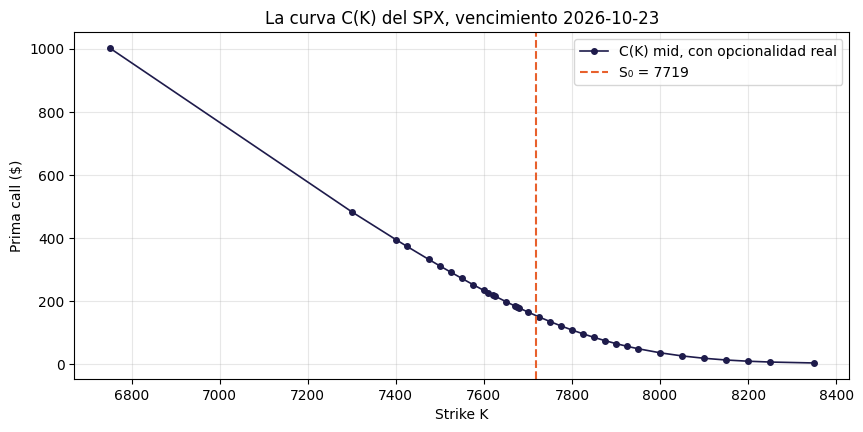

In [4]:
# ── Paso 3: tests de monotonicidad y convexidad ───────────────────────────────
# Dos filtros antes del test:
#  (a) spread < 15%: el mid de opciones ilíquidas no es un precio tradeble
#  (b) valor temporal > $0.50: las calls deep ITM tienen tv ≈ 0 (precio rancio , 
#      nadie las tradea, el mercado real usa la put equivalente vía paridad).
#      Las calls deep OTM también quedan afuera: su "mid" es 1-2 ticks mínimos.
#      En ambos extremos no hay convexidad interesante que testear.
intrin = np.maximum(S0 - calls.index.values, 0)
calls['time_val'] = calls['mid'].values - intrin

calls_liq = calls[(calls['sprd'] < 0.15) & (calls['time_val'] > 0.50)].copy()

K = calls_liq.index.values
C = calls_liq['mid'].values

print(f'Calls totales tras limpiar(): {len(calls)} | con opcionalidad real (tv>$0.50, sprd<15%): {len(calls_liq)}')
print(f'Rango de strikes: {K.min():.0f} – {K.max():.0f}  (spot S₀ = {S0:.0f})')

# Monotonicidad: C(K) debe DECRECER → toda diferencia positiva es una violación
viol_mono = np.where(np.diff(C) > 0)[0]
print(f'\nMonotonicidad: {len(viol_mono)} violaciones en {len(K)-1} pares de strikes')

# Convexidad: C_i no puede superar la interpolación lineal de sus vecinos
if len(K) >= 3:
    interp_vecinos = C[:-2] + (K[1:-1] - K[:-2]) / (K[2:] - K[:-2]) * (C[2:] - C[:-2])
    viol_conv = np.where(C[1:-1] > interp_vecinos + 1e-9)[0]
    print(f'Convexidad   : {len(viol_conv)} violaciones en {len(K)-2} tripletes')
else:
    viol_conv = np.array([], dtype=int)
    print('Convexidad   : no hay suficientes strikes para el test')

if len(viol_conv):
    print('\nStrikes con butterfly "negativo":', K[viol_conv + 1])

plt.plot(K, C, 'o-', color=NAVY, ms=4, lw=1.2, label='C(K) mid, con opcionalidad real')
if len(viol_conv):
    plt.scatter(K[viol_conv + 1], C[viol_conv + 1],
                color=RED, zorder=3, s=60, label='violación de convexidad')
plt.axvline(S0, color=ORANGE, ls='--', label=f'S₀ = {S0:.0f}')
plt.xlabel('Strike K'); plt.ylabel('Prima call ($)')
plt.title(f'La curva C(K) del SPX, vencimiento {expiry}')
plt.legend(); plt.show()

### ¿Arbitraje gratis? Intentemos ejecutarlo

Los butterflies "negativos" de arriba están calculados con el **mid** = (bid+ask)/2, y el mid
**no es un precio al que se pueda operar**: es el promedio entre donde el mercado te *vende*
(ask) y donde te *compra* (bid).

Para ejecutar de verdad el arbitraje del butterfly hay que **cruzar el spread en las tres patas**:

$$\text{costo real} = (1-w)\cdot \text{ask}(K_1)\; -\; \text{bid}(K_2)\; +\; w\cdot \text{ask}(K_3) \qquad w = \tfrac{K_2-K_1}{K_3-K_1}$$

comprás las alas al **ask** (caro) y vendés el cuerpo al **bid** (barato).


In [5]:
# ── El butterfly "negativo", puesto a ejecutar: mid vs precios operables ──────
if len(viol_conv):
    filas = []
    print(f'{"K1":>7}{"K2":>7}{"K3":>7}{"C(K1)":>9}{"C(K2)":>9}{"C(K3)":>9}{"fly a MID":>12}{"fly EJECUTABLE":>16}   veredicto')
    for j in viol_conv:
        k1, k2, k3 = K[j], K[j+1], K[j+2]
        w = (k2 - k1) / (k3 - k1)
        c1, c2, c3 = calls_liq.loc[k1,'mid'], calls_liq.loc[k2,'mid'], calls_liq.loc[k3,'mid']
        fly_mid  = (1-w)*c1 - c2 + w*c3
        fly_ejec = (1-w)*calls_liq.loc[k1,'ask'] - calls_liq.loc[k2,'bid'] + w*calls_liq.loc[k3,'ask']
        veredicto = 'se evaporó' if fly_ejec >= 0 else '¡¡REVISAR!!'
        print(f'{k1:>7.0f}{k2:>7.0f}{k3:>7.0f}{c1:>9.2f}{c2:>9.2f}{c3:>9.2f}{fly_mid:>12.3f}{fly_ejec:>16.3f}   {veredicto}')
        filas.append(dict(K1=int(k1), K2=int(k2), K3=int(k3), w=round(w, 4),
                          bid1=calls_liq.loc[k1,'bid'], ask1=calls_liq.loc[k1,'ask'], mid1=calls_liq.loc[k1,'mid'],
                          bid2=calls_liq.loc[k2,'bid'], ask2=calls_liq.loc[k2,'ask'], mid2=calls_liq.loc[k2,'mid'],
                          bid3=calls_liq.loc[k3,'bid'], ask3=calls_liq.loc[k3,'ask'], mid3=calls_liq.loc[k3,'mid'],
                          fly_mid=round(fly_mid, 3), fly_ejec=round(fly_ejec, 3)))

    # ── Tabla completa para verificar a mano ──────────────────────────────────
    print('\n── Precios completos de cada pata ──────────────────────────────────────────')
    print('  fly_mid  = (1-w)·mid₁ − mid₂ + w·mid₃    ← "violación" a mid')
    print('  fly_ejec = (1-w)·ask₁ − bid₂ + w·ask₃    ← lo que cuesta ejecutar')
    df_tab = pd.DataFrame(filas)
    df_tab.columns = ['K₁','K₂','K₃','w',
                      'bid₁','ask₁','mid₁',
                      'bid₂','ask₂','mid₂',
                      'bid₃','ask₃','mid₃',
                      'fly_mid','fly_ejec']
    display(df_tab.to_string(
        index=False,
        formatters={
            'w':        lambda v: f'{v:.4f}',
            'bid₁':     lambda v: f'{v:.2f}', 'ask₁': lambda v: f'{v:.2f}', 'mid₁': lambda v: f'{v:.2f}',
            'bid₂':     lambda v: f'{v:.2f}', 'ask₂': lambda v: f'{v:.2f}', 'mid₂': lambda v: f'{v:.2f}',
            'bid₃':     lambda v: f'{v:.2f}', 'ask₃': lambda v: f'{v:.2f}', 'mid₃': lambda v: f'{v:.2f}',
            'fly_mid':  lambda v: f'{v:+.3f}',
            'fly_ejec': lambda v: f'{v:+.3f}',
        }
    ))

    # ── Verificación paso a paso para el primer butterfly ─────────────────────
    r0 = filas[0]
    print(f'\n── Verificación manual (butterfly {r0["K1"]}/{r0["K2"]}/{r0["K3"]}) ──────────────────')
    print(f'  w        = ({r0["K2"]}−{r0["K1"]})/({r0["K3"]}−{r0["K1"]}) = {r0["w"]:.4f}')
    print(f'  fly_mid  = (1−{r0["w"]:.4f})×{r0["mid1"]:.2f} − {r0["mid2"]:.2f} + {r0["w"]:.4f}×{r0["mid3"]:.2f}')
    print(f'           = {(1-r0["w"])*r0["mid1"]:.3f} − {r0["mid2"]:.3f} + {r0["w"]*r0["mid3"]:.3f} = {r0["fly_mid"]:+.3f}  ← negativo')
    print(f'  fly_ejec = (1−{r0["w"]:.4f})×{r0["ask1"]:.2f} − {r0["bid2"]:.2f} + {r0["w"]:.4f}×{r0["ask3"]:.2f}')
    print(f'           = {(1-r0["w"])*r0["ask1"]:.3f} − {r0["bid2"]:.3f} + {r0["w"]*r0["ask3"]:.3f} = {r0["fly_ejec"]:+.3f}  ← arbitraje evaporado')
    print(f'  spread consumido = {r0["fly_ejec"] - r0["fly_mid"]:+.3f}')

    # ── El cuadro: la "violación" a mid vs el costo real de ejecutarla ────────
    etiquetas = [f'{f["K1"]}/{f["K2"]}/{f["K3"]}' for f in filas]
    x = np.arange(len(filas))
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(x - 0.18, [f['fly_mid']  for f in filas], width=0.36, color=RED,
           label='a precios MID (el promedio que nadie tradea)')
    ax.bar(x + 0.18, [f['fly_ejec'] for f in filas], width=0.36, color=GREEN,
           label='EJECUTABLE (alas al ask, cuerpo al bid)')
    ax.axhline(0, color=NAVY, lw=1.2)
    ax.set_xticks(x); ax.set_xticklabels(etiquetas, fontsize=9)
    ax.set_xlabel('strikes del butterfly (K₁/K₂/K₃)')
    ax.set_ylabel('costo del butterfly ($)')
    ax.set_title('El "arbitraje" que se evapora: la violación existe en el mid, no en el mercado')
    for xi, f in zip(x, filas):
        ax.annotate(f'{f["fly_mid"]:+.2f}', (xi - 0.18, f['fly_mid']), ha='center', va='top',
                    fontsize=9, color=RED, xytext=(0, -4), textcoords='offset points')
        ax.annotate(f'{f["fly_ejec"]:+.2f}', (xi + 0.18, f['fly_ejec']), ha='center', va='bottom',
                    fontsize=9, color=GREEN, xytext=(0, 3), textcoords='offset points')
    ax.legend(fontsize=9)
    plt.show()

else:
    print('Hoy no hubo violaciones a mid, correr un día de más volatilidad para ver el efecto.')

Hoy no hubo violaciones a mid, correr un día de más volatilidad para ver el efecto.


Regresión sobre 25 strikes en [7300, 8000]
Pendiente = -0.99531  →  tasa implícita  r = 3.65%
Ordenada  = 7706.64  →  div. implícito  q = 1.20%  (el S&P rinde ~1.3-1.5%)

Tesoro (T-bill 3m, ^IRX): 3.76%  |  diferencia: 11 bp


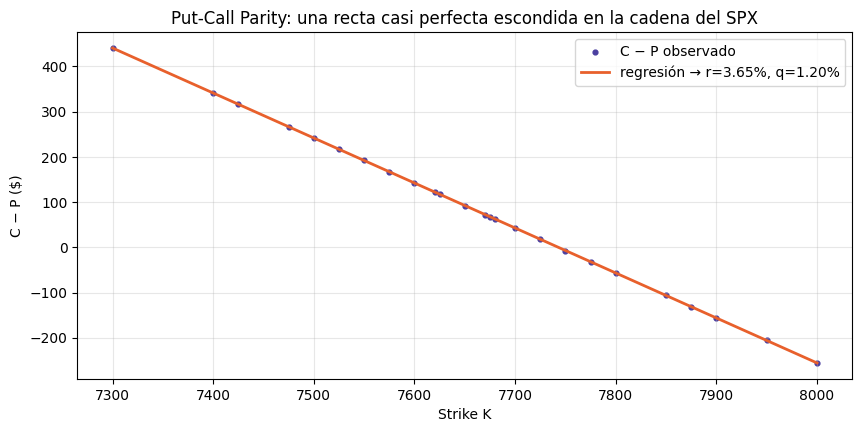

In [6]:
# ── Paso 4: put-call parity como regresión → tasa y dividendo implícitos ─────
# Regresión SOLO cerca del dinero (±10%) y con spreads sanos: ahí la liquidez es real
K_reg = K_comun[(K_comun > 0.90*S0) & (K_comun < 1.10*S0)]
K_reg = K_reg[(calls.loc[K_reg, 'sprd'] < 0.6) & (puts.loc[K_reg, 'sprd'] < 0.6)]

C_com = calls.loc[K_reg, 'mid'].values
P_com = puts.loc[K_reg, 'mid'].values
Kc = K_reg.values

# C - P = S·e^{-qT} - K·e^{-rT}  →  lineal en K: pendiente -e^{-rT}, ordenada S·e^{-qT}
pendiente, ordenada = np.polyfit(Kc, C_com - P_com, 1)

r_impl = -np.log(-pendiente) / T_opt
q_impl = -np.log(ordenada / S0) / T_opt

# Referencia del Tesoro al mismo plazo: ^IRX (13 semanas, cotiza el rendimiento en %)
try:
    r_tesoro = float(yf.Ticker('^IRX').history(period='5d')['Close'].iloc[-1]) / 100
except Exception:
    r_tesoro = 0.0384                     # respaldo: T-bill 3m, 18-jul-2026

print(f'Regresión sobre {len(Kc)} strikes en [{Kc.min():.0f}, {Kc.max():.0f}]')
print(f'Pendiente = {pendiente:.5f}  →  tasa implícita  r = {r_impl*100:.2f}%')
print(f'Ordenada  = {ordenada:.2f}  →  div. implícito  q = {q_impl*100:.2f}%  (el S&P rinde ~1.3-1.5%)')
print(f'\nTesoro (T-bill 3m, ^IRX): {r_tesoro*100:.2f}%  |  diferencia: {abs(r_impl-r_tesoro)*10_000:.0f} bp')

plt.scatter(Kc, C_com - P_com, s=12, color=VIOLET, label='C − P observado')
plt.plot(Kc, ordenada + pendiente*Kc, color=ORANGE, lw=2,
         label=f'regresión → r={r_impl*100:.2f}%, q={q_impl*100:.2f}%')
plt.xlabel('Strike K'); plt.ylabel('C − P ($)')
plt.title('Put-Call Parity: una recta casi perfecta escondida en la cadena del SPX')
plt.legend(); plt.show()

### Repetir la regresión con SPY (opciones americanas)

La Put-Call Parity **como igualdad** solo vale para europeas. Repitan la misma regresión de
la celda anterior, ahora con `yf.Ticker('SPY')` — sus opciones son **americanas**. La pregunta
de esta sección es qué le pasa a la tasa implícita, y por qué.


[datos en vivo, SPY 2026-10-23 (T=0.13a)]
SPX (europeas):  pendiente -0.99531  →  r implícita +3.65%   ✓ razonable
SPY (americanas): pendiente -1.00805  →  r implícita -6.22%   ✗ absurda


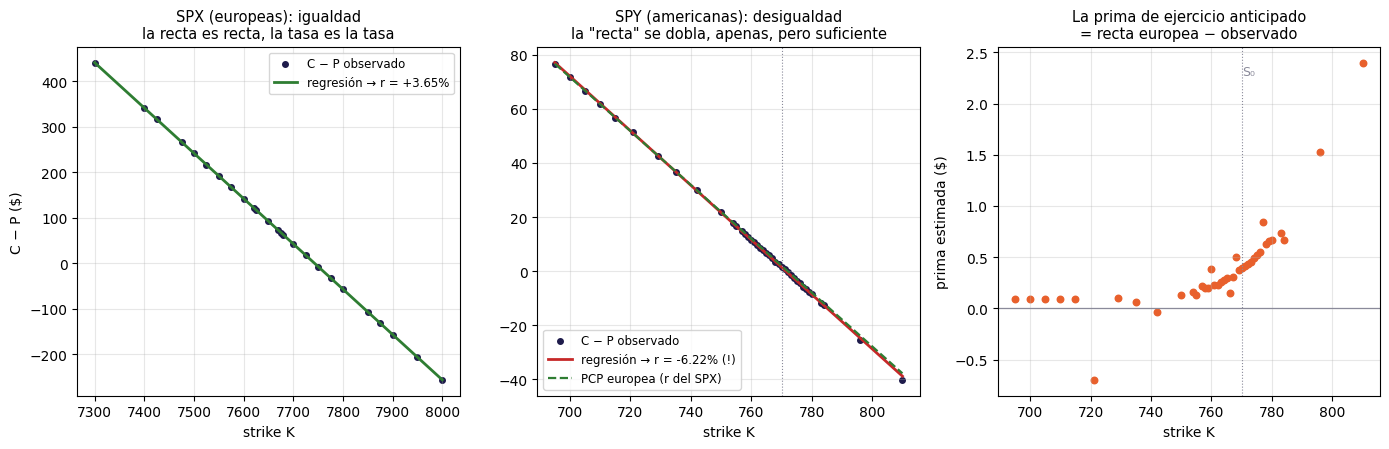

In [7]:
# ── SPY (americanas): misma limpieza, misma regresión, resultado opuesto ─────
try:
    spy_tk = yf.Ticker('SPY')
    S0_spy = float(spy_tk.history(period='1d')['Close'].iloc[-1])
    dias_spy = {e: (pd.Timestamp(e) - hoy).days for e in spy_tk.options}
    expiry_spy = next(e for e, d in dias_spy.items() if 45 <= d <= 120)
    T_spy = dias_spy[expiry_spy] / 365
    cad = spy_tk.option_chain(expiry_spy)

    def limpiar_spy(df):                       # como limpiar(), pero con el S0 del SPY (no el del SPX)
        df = df[['strike', 'bid', 'ask', 'openInterest', 'volume']].copy()
        df = df[(df.bid > 0) & (df.ask > 0)]
        df['mid']  = (df.bid + df.ask) / 2
        df['sprd'] = (df.ask - df.bid) / df.mid
        df = df[(df.strike > 0.75*S0_spy) & (df.strike < 1.25*S0_spy)]
        df = df[(df.openInterest.fillna(0) > 0) | (df.volume.fillna(0) > 0)]   # mismo filtro de liquidez
        return df.set_index('strike').sort_index()

    calls_spy, puts_spy = limpiar_spy(cad.calls), limpiar_spy(cad.puts)
    fuente_spy = f'datos en vivo, SPY {expiry_spy} (T={T_spy:.2f}a)'
except Exception as e:
    # Respaldo sintético: la recta europea + prima de ejercicio creciente en K (forma típica)
    rng_fb = np.random.default_rng(11)
    S0_spy, T_spy = 745.0, 0.13
    Kx = np.arange(670, 820, 5).astype(float)
    recta = S0_spy*np.exp(-0.013*T_spy) - Kx*np.exp(-0.037*T_spy)
    prima = 0.12*np.maximum(Kx - S0_spy, 0)*T_spy*4          # crece con el strike ITM del put
    cmp_ = recta - prima + rng_fb.normal(0, 0.05, len(Kx))
    calls_spy = pd.DataFrame({'mid': np.maximum(cmp_, 0)+5, 'sprd': 0.1}, index=Kx)
    puts_spy  = pd.DataFrame({'mid': calls_spy['mid'] - cmp_, 'sprd': 0.1}, index=Kx)
    fuente_spy = f'⚠ respaldo sintético ({e})'

# misma banda ±10% y filtro de spread que el SPX
K_spy = calls_spy.index.intersection(puts_spy.index)
K_spy = K_spy[(K_spy > 0.90*S0_spy) & (K_spy < 1.10*S0_spy)]
K_spy = K_spy[(calls_spy.loc[K_spy,'sprd'] < 0.6) & (puts_spy.loc[K_spy,'sprd'] < 0.6)]
cmp_spy = (calls_spy.loc[K_spy,'mid'] - puts_spy.loc[K_spy,'mid']).values
Ks = np.asarray(K_spy, dtype=float)

pend_spy, ord_spy = np.polyfit(Ks, cmp_spy, 1)
r_spy = -np.log(-pend_spy) / T_spy
print(f'[{fuente_spy}]')
print(f'SPX (europeas):  pendiente {pendiente:.5f}  →  r implícita {r_impl*100:+.2f}%   ✓ razonable')
print(f'SPY (americanas): pendiente {pend_spy:.5f}  →  r implícita {r_spy*100:+.2f}%   ✗ absurda')

# ── El gráfico: la recta que funciona, la que se tuerce, y la prima extraída ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))

axes[0].scatter(Kc, C_com - P_com, s=16, color=NAVY, label='C − P observado')
axes[0].plot(Kc, pendiente*Kc + ordenada, color=GREEN, lw=2,
             label=f'regresión → r = {r_impl*100:+.2f}%')
axes[0].set_title('SPX (europeas): igualdad\nla recta es recta, la tasa es la tasa', fontsize=10.5)
axes[0].set_xlabel('strike K'); axes[0].set_ylabel('C − P ($)')
axes[0].legend(fontsize=8.5)

# referencia europea para SPY: pendiente con la r del SPX, anclada en strikes bajos (puts OTM, prima ≈ 0)
pend_eur = -np.exp(-r_impl*T_spy)
n_low = max(3, len(Ks)//4)
ord_eur = np.mean(cmp_spy[:n_low] - pend_eur*Ks[:n_low])

axes[1].scatter(Ks, cmp_spy, s=16, color=NAVY, label='C − P observado')
axes[1].plot(Ks, pend_spy*Ks + ord_spy, color=RED, lw=2,
             label=f'regresión → r = {r_spy*100:+.2f}% (!)')
axes[1].plot(Ks, pend_eur*Ks + ord_eur, color=GREEN, lw=1.6, ls='--',
             label='PCP europea (r del SPX)')
axes[1].axvline(S0_spy, color='#8A8A9A', lw=0.8, ls=':')
axes[1].set_title('SPY (americanas): desigualdad\nla "recta" se dobla, apenas, pero suficiente', fontsize=10.5)
axes[1].set_xlabel('strike K')
axes[1].legend(fontsize=8.5)

# la prima de ejercicio anticipado, EXTRAÍDA: recta europea − observado
prima = (pend_eur*Ks + ord_eur) - cmp_spy
axes[2].scatter(Ks, prima, s=22, color=ORANGE)
axes[2].axhline(0, color='#8A8A9A', lw=0.9)
axes[2].axvline(S0_spy, color='#8A8A9A', lw=0.8, ls=':')
axes[2].annotate('S₀', (S0_spy, prima.max()*0.95), fontsize=9, color='#8A8A9A', ha='left')
axes[2].set_title('La prima de ejercicio anticipado\n= recta europea − observado', fontsize=10.5)
axes[2].set_xlabel('strike K'); axes[2].set_ylabel('prima estimada ($)')
plt.tight_layout(); plt.show()


---
# Ejercicio 2, El smile: invertir Black-Scholes contra el mercado

## La idea

Black-Scholes dice: dado $\sigma$, el precio. El mercado nos da lo inverso: dado el **precio**, ¿qué $\sigma$
está pagando? Esa es la **volatilidad implícita**:

$$\sigma_{impl}(K) \;=\; \text{la } \sigma \text{ tal que } BS(S_0, K, T, r, q, \sigma) = \text{precio de mercado}$$

No tiene fórmula cerrada → se resuelve con `brentq` (búsqueda de raíz, como el YTM de la clase 1).

**Si BS fuera verdad**, $\sigma_{impl}(K)$ sería una recta horizontal: la misma constante para todo strike.
Vamos a ver qué dice el SPX.

**Dos detalles de práctica profesional:**
- Usamos $r$ y $q$ **implícitos del Ejercicio 2** (consistencia: son los que el propio mercado usa).
- Invertimos las opciones **OTM de cada lado** (puts para $K<S_0$, calls para $K>S_0$): son las más líquidas
  y las menos contaminadas por el valor intrínseco.

In [8]:
# ── Black-Scholes con dividendo continuo + inversor de volatilidad ───────────
def bs_precio(S, Kk, T, r, q, sigma, tipo='call'):
    d1 = (np.log(S/Kk) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if tipo == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - Kk*np.exp(-r*T)*norm.cdf(d2)
    return Kk*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

def vol_implicita(precio, S, Kk, T, r, q, tipo='call'):
    objetivo = lambda s: bs_precio(S, Kk, T, r, q, s, tipo) - precio
    try:
        return brentq(objetivo, 1e-4, 3.0)      # buscar σ en (0.01%, 300%)
    except ValueError:
        return np.nan                            # precio fuera de las cotas de no-arbitraje

# Sanity check del pricer: la PCP se debe cumplir a máquina
c_test = bs_precio(100, 100, 0.5, 0.04, 0.01, 0.2, 'call')
p_test = bs_precio(100, 100, 0.5, 0.04, 0.01, 0.2, 'put')
pcp = c_test - p_test - (100*np.exp(-0.01*0.5) - 100*np.exp(-0.04*0.5))
print(f'Call test = {c_test:.4f} | Put test = {p_test:.4f} | error PCP = {pcp:.2e}  ✓')

Call test = 6.3393 | Put test = 4.8579 | error PCP = 0.00e+00  ✓


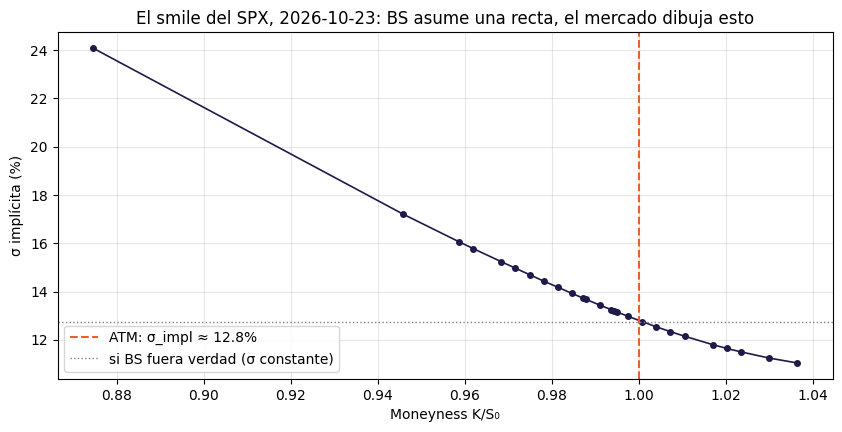

IV en K/S₀≈0.87 (put OTM más lejano líquido hoy): 24.1%
IV ATM                                        : 12.8%


In [9]:
# ── Invertir la cadena: OTM de cada lado, sólo strikes líquidos ────────────────
smile = []
for Kk in K_comun:
    if Kk < S0:   # lado izquierdo: put OTM
        fila, tipo = puts.loc[Kk], 'put'
    else:         # lado derecho: call OTM
        fila, tipo = calls.loc[Kk], 'call'
    if fila['sprd'] > 0.5:                # spread mayor al 50% del mid: cotización zombie
        continue
    iv = vol_implicita(fila['mid'], S0, Kk, T_opt, r_impl, q_impl, tipo)
    smile.append((Kk / S0, iv))

smile = pd.DataFrame(smile, columns=['moneyness', 'iv']).dropna().sort_values('moneyness').reset_index(drop=True)
iv_atm = smile.iloc[(smile.moneyness - 1).abs().argmin()]['iv']

plt.plot(smile.moneyness, smile.iv*100, 'o-', color=NAVY, ms=4, lw=1.2)
plt.axvline(1.0, color=ORANGE, ls='--', label=f'ATM: σ_impl ≈ {iv_atm*100:.1f}%')
plt.axhline(iv_atm*100, color='gray', ls=':', lw=1, label='si BS fuera verdad (σ constante)')
plt.xlabel('Moneyness K/S₀'); plt.ylabel('σ implícita (%)')
plt.title(f'El smile del SPX, {expiry}: BS asume una recta, el mercado dibuja esto')
plt.legend(); plt.show()

# El put OTM más lejano LÍQUIDO disponible hoy (no un umbral fijo: qué strike sobrevive
# el filtro de spread cambia día a día, quedarse con lo que el mercado realmente ofrece).
otm_lejano = smile.iloc[0]
print(f"IV en K/S₀≈{otm_lejano.moneyness:.2f} (put OTM más lejano líquido hoy): {otm_lejano.iv*100:.1f}%")
print(f'IV ATM                                        : {iv_atm*100:.1f}%')

### Bonus (si hay tiempo), Breeden-Litzenberger: la densidad que el mercado publica

Del teórico §2: $\;\partial^2 C/\partial K^2 = e^{-rT} q(K)\;$, derivar dos veces la curva de calls
recupera la **densidad de probabilidad neutral al riesgo** de $S_T$. Receta numérica: suavizar el smile
(polinomio), repreciar calls con BS sobre una grilla fina, y tomar segundas diferencias.

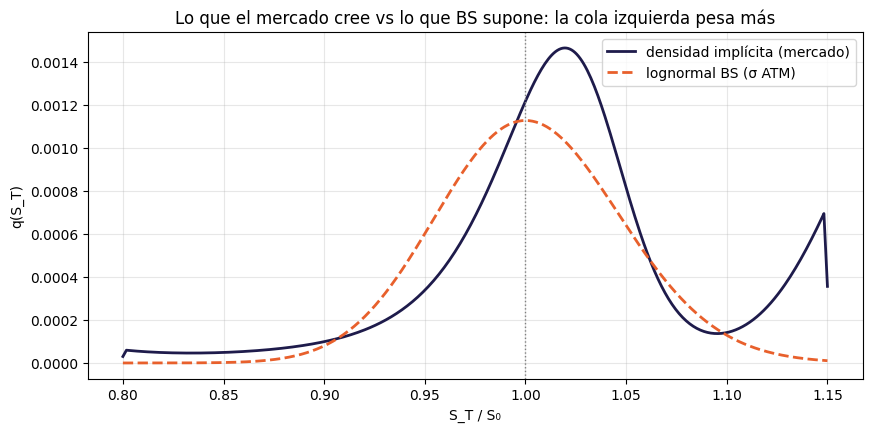

In [10]:
# ── Breeden-Litzenberger en 10 líneas ─────────────────────────────────────────
coef = np.polyfit(smile.moneyness, smile.iv, deg=4)       # smile suavizado
K_fina = np.linspace(0.80*S0, 1.15*S0, 400)
iv_fina = np.polyval(coef, K_fina/S0)

C_fina = bs_precio(S0, K_fina, T_opt, r_impl, q_impl, iv_fina, 'call')
densidad = np.exp(r_impl*T_opt) * np.gradient(np.gradient(C_fina, K_fina), K_fina)

# Comparación: la lognormal que BS "cree" con la σ ATM
mu_ln = np.log(S0) + (r_impl - q_impl - 0.5*iv_atm**2)*T_opt
lognormal = norm.pdf(np.log(K_fina), mu_ln, iv_atm*np.sqrt(T_opt)) / K_fina

plt.plot(K_fina/S0, densidad, color=NAVY, lw=2, label='densidad implícita (mercado)')
plt.plot(K_fina/S0, lognormal, color=ORANGE, ls='--', lw=2, label='lognormal BS (σ ATM)')
plt.axvline(1.0, color='gray', ls=':', lw=1)
plt.xlabel('S_T / S₀'); plt.ylabel('q(S_T)')
plt.title('Lo que el mercado cree vs lo que BS supone: la cola izquierda pesa más')
plt.legend(); plt.show()

---
# Ejercicio 3, Simulador de delta-hedging: cosechar $\sigma_{real} - \sigma_{impl}$

## La posición

Comprás una call pagando su precio Black-Scholes a la vol implícita $\sigma_{impl} = 20\%$, y
la delta-hedgeás vendiendo en corto $\Delta = \partial C/\partial S$ acciones, rebalanceando el
short cada vez que $\Delta$ cambia. La identidad que vamos a verificar por fuerza bruta (teórico §4):

$$\text{P\&L} \;=\; \int_0^T \tfrac{1}{2}\,\Gamma\, S^2\,\bigl(\sigma_{real}^2 - \sigma_{impl}^2\bigr)\,dt$$

## El experimento

Simulamos 5.000 caminos GBM con una $\sigma_{real}$ que nosotros controlamos, compramos la call
a $\sigma_{impl}=20\%$, y delta-hedgeamos todos los días con este protocolo:
1. Recalcular $\Delta = e^{-q\tau}N(d_1)$ con la $\sigma_{impl}$ (te cubrís con la vol a la que valuaste).
2. Ajustar la posición corta en acciones a $-\Delta$; la diferencia entra o sale de la cuenta de caja.
3. La caja devenga la tasa $r$.

**Trampa deliberada:** el drift real es $\mu = 10\%$, bien distinto de $r = 4\%$.


### La contabilidad del simulador: tres cuentas, línea por línea

El código de abajo lleva la posición del trader en **tres cuentas**, y conviene leerlas antes de correrlo:

| Cuenta | Qué es | Dónde vive en el código |
|---|---|---|
| la call | comprada al inicio, se queda quieta hasta T | su valor final es el payoff `max(ST−K, 0)` |
| el short de acciones | siempre $-\Delta$ acciones (se rebalancea) | `delta` |
| la caja | todo el efectivo que entra y sale | `caja` |

**Día 0**, pagás la prima y armás el short:
`caja = -C0 + delta*S0` → sale la prima $C_0$, entra lo que cobrás por shortear $\Delta_0$ acciones a $S_0$.

**Cada día**, tres movimientos:
1. `caja *= exp(r*dt)` → la caja devenga interés (si es negativa, pagás por el préstamo).
2. `delta_new = delta_bs(...)` → recalculás la cobertura con el S de hoy.
3. `caja += (delta_new - delta)*S` → el rebalanceo: si $\Delta$ subió, shorteás más acciones y
   entra efectivo (vendés caro); si bajó, recomprás y sale efectivo (comprás barato). **Acá es
   donde se cosecha la convexidad del Paso 1**, no hay ninguna fórmula de gamma en el código:
   la cosecha emerge sola de rebalancear.

**Día T**, se cierra todo, y esa es la fórmula del P&L final:

$$\text{P\&L} \;=\; \underbrace{\max(S_T-K,\,0)}_{\text{cobrás el payoff de la call}} \;\underbrace{-\;\Delta\, S_T}_{\text{recomprás las } \Delta \text{ acciones del short}} \;+\; \underbrace{\text{caja}}_{\text{lo acumulado por prima, rebalanceos e interés}}$$

Como la riqueza inicial era cero (todo lo que pagaste salió de la caja), este total ES el P&L.
Si la identidad del Paso 2 es cierta, su promedio sobre los 5.000 caminos tiene que dar
$\approx BS(\sigma_{real}) - BS(\sigma_{impl})$, la columna "teórico" de la tabla.

In [11]:
# ── El simulador (vectorizado sobre caminos) ──────────────────────────────────
def delta_bs(S, Kk, tau, r, q, sigma):
    d1 = (np.log(S/Kk) + (r - q + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    return np.exp(-q*tau) * norm.cdf(d1)

def simular_hedge(sigma_real, sigma_impl, S0=100., K=100., T=0.25, r=0.04, q=0.0,
                  mu=0.10, pasos=63, n_paths=5000, seed=7):
    """Compra 1 call a BS(sigma_impl), delta-hedgea 'pasos' veces. Devuelve P&L final por camino."""
    rng = np.random.default_rng(seed)
    dt = T / pasos

    # Caminos GBM bajo la medida REAL (drift mu, vol sigma_real)
    z = rng.standard_normal((n_paths, pasos))
    S = S0 * np.exp(np.cumsum((mu - 0.5*sigma_real**2)*dt + sigma_real*np.sqrt(dt)*z, axis=1))
    S = np.hstack([np.full((n_paths, 1), S0), S])

    C0 = bs_precio(S0, K, T, r, q, sigma_impl, 'call')
    delta = delta_bs(S0, K, T, r, q, sigma_impl)
    caja = -C0 + delta * S0                      # pago la call, cobro el short de Δ acciones

    for i in range(1, pasos):
        tau = T - i*dt
        caja *= np.exp(r*dt)                     # la caja devenga la tasa
        delta_new = delta_bs(S[:, i], K, tau, r, q, sigma_impl)
        caja += (delta_new - delta) * S[:, i]    # rebalanceo: shortear más suma caja
        delta = delta_new

    caja *= np.exp(r*dt)
    ST = S[:, -1]
    return np.maximum(ST - K, 0) - delta*ST + caja   # payoff + cerrar el short + caja

C0 = bs_precio(100, 100, 0.25, 0.04, 0.0, 0.20, 'call')
print(f'Prima pagada (σ_impl=20%): {C0:.3f}')
print(f'Breakeven diario: |ΔS|/S = 20%/√252 = {0.20/np.sqrt(252)*100:.2f}% por día')

Prima pagada (σ_impl=20%): 4.485
Breakeven diario: |ΔS|/S = 20%/√252 = 1.26% por día


escenario                                P&L medio      std  teórico aprox*
σ_real = 25% (compraste barato)             +0.989    0.695          +0.987
σ_real = 20% (= implícita)                  -0.003    0.436          +0.000
σ_real = 15% (compraste caro)               -0.983    0.461          -0.985

* teórico aprox = BS(σ_real) − BS(σ_impl): la ganancia por vol mal pagada


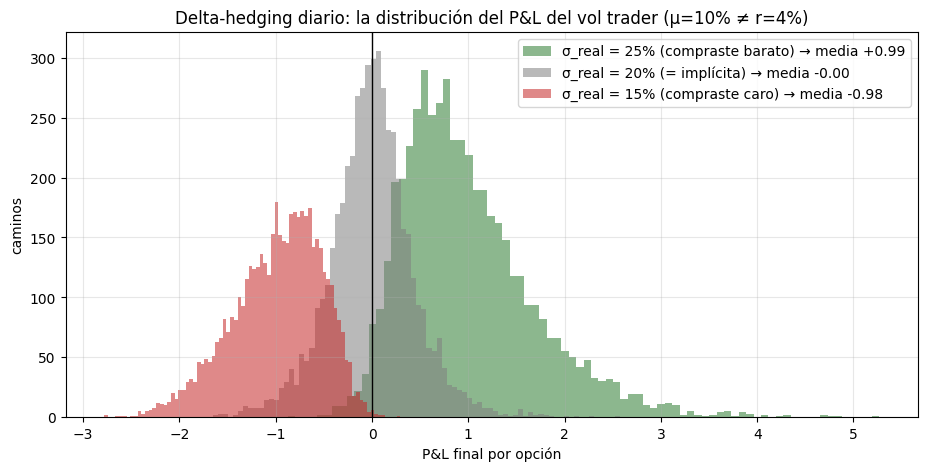

In [12]:
# ── Tres escenarios: tener razón, estar equivocado, y el caso neutro ──────────
escenarios = {'σ_real = 25% (compraste barato)': (0.25, GREEN),
              'σ_real = 20% (= implícita)'     : (0.20, 'gray'),
              'σ_real = 15% (compraste caro)'  : (0.15, RED)}

fig, ax = plt.subplots(figsize=(11, 5))
print(f'{"escenario":<38}{"P&L medio":>12}{"std":>9}{"teórico aprox*":>16}')
for nombre, (s_real, color) in escenarios.items():
    pnl = simular_hedge(sigma_real=s_real, sigma_impl=0.20)
    teorico = bs_precio(100, 100, 0.25, 0.04, 0.0, s_real, 'call') - C0
    print(f'{nombre:<38}{pnl.mean():>+12.3f}{pnl.std():>9.3f}{teorico:>+16.3f}')
    ax.hist(pnl, bins=80, alpha=0.55, color=color, label=f'{nombre} → media {pnl.mean():+.2f}')

print('\n* teórico aprox = BS(σ_real) − BS(σ_impl): la ganancia por vol mal pagada')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('P&L final por opción'); ax.set_ylabel('caminos')
ax.set_title('Delta-hedging diario: la distribución del P&L del vol trader (μ=10% ≠ r=4%)')
ax.legend(); plt.show()

In [13]:
# ── El efecto de la frecuencia de rebalanceo ──────────────────────────────────
# Con σ_real = σ_impl el P&L medio es ~0: todo lo que queda es RUIDO de hedge discreto.
# La teoría dice que ese ruido cae como 1/√(n_rebalanceos).
print(f'{"rebalanceos en 3 meses":>24}{"P&L medio":>12}{"std del P&L":>14}')
for pasos in [5, 13, 63, 252]:
    pnl = simular_hedge(sigma_real=0.20, sigma_impl=0.20, pasos=pasos)
    print(f'{pasos:>24}{pnl.mean():>+12.3f}{pnl.std():>14.3f}')

  rebalanceos en 3 meses   P&L medio   std del P&L
                       5      -0.027         1.445
                      13      -0.003         0.932
                      63      -0.003         0.436
                     252      -0.001         0.217


---
# Ejercicio 4, Delta-hedging con datos reales: ¿vendiste vol y ganaste?

## La misma cuenta del Ejercicio 3, pero sin simular nada

Repetimos exactamente la misma contabilidad (comprar/vender una opción, delta-hedgear día a
día, cerrar en T) pero con:

- **σ_impl real**: el **VIX** del día, la volatilidad implícita a 30 días que el mercado de
  opciones del S&P 500 está cotizando ese día.
- **El path real**: los precios de cierre reales de SPY durante los ~21 días hábiles
  siguientes (≈ un mes calendario).

Repetimos esto en **ventanas mensuales no superpuestas** a lo largo de ~20 años de historia,
mirándolo desde el lado del **vendedor** de la opción (el signo opuesto al del Ejercicio 3):
es la posición de un market maker o un fondo de "risk premia" que vende volatilidad
sistemáticamente.


In [14]:
# ── Datos: SPY (el path a hedgear) y VIX (la σ_impl que el mercado cotiza) ────
try:
    datos_real = yf.download(['SPY', '^VIX'], start='2005-01-01', progress=False)['Close'].dropna()
    fuente_real = 'datos en vivo (Yahoo Finance)'
except Exception as e:
    fuente_real = f'⚠ respaldo sintético fechado 9-ago-2026 ({e})'
    rng_fb = np.random.default_rng(5)
    idx_fb = pd.date_range('2005-01-03', periods=5433, freq='B')
    spy_fb = 100 * np.cumprod(1 + rng_fb.normal(0.0003, 0.011, 5433))
    vix_fb = np.clip(18 + np.cumsum(rng_fb.normal(0, 0.5, 5433)) * 0.05, 9, 80)
    datos_real = pd.DataFrame({'SPY': spy_fb, '^VIX': vix_fb}, index=idx_fb)

print(f'[{fuente_real}] {len(datos_real)} días, {datos_real.index[0].date()} → {datos_real.index[-1].date()}')
datos_real.tail(3)

[datos en vivo (Yahoo Finance)] 5453 días, 2005-01-03 → 2026-09-04


Ticker,SPY,^VIX
Date,,
2026-09-02,765.159973,15.20
2026-09-03,773.169983,14.32
2026-09-04,770.190002,14.53


In [15]:
# ── Reusa bs_precio y delta_bs del Ejercicio 3, con un path REAL en vez de simulado ──
def hedge_pnl_real(precios, r, q, sigma_impl):
    """Compra 1 call ATM a sigma_impl, delta-hedgea día a día sobre el path REAL dado.
    Devuelve el P&L del COMPRADOR, como fracción del precio inicial (comparable entre épocas)."""
    pasos = len(precios) - 1
    T, dt = pasos / 252, 1 / 252
    K = precios[0]
    C0 = bs_precio(precios[0], K, T, r, q, sigma_impl, 'call')
    delta = delta_bs(precios[0], K, T, r, q, sigma_impl)
    caja = -C0 + delta * precios[0]
    for i in range(1, pasos):
        tau = max(T - i * dt, 1e-6)
        caja *= np.exp(r * dt)
        delta_new = delta_bs(precios[i], K, tau, r, q, sigma_impl)
        caja += (delta_new - delta) * precios[i]
        delta = delta_new
    caja *= np.exp(r * dt)
    ST = precios[-1]
    return (np.maximum(ST - K, 0) - delta * ST + caja) / precios[0]

VENTANA = 21      # ~1 mes hábil, la misma malla temporal que el VIX (30 días corridos)
r_libre = 0.03    # tasa libre de riesgo aprox, no mueve la conclusión

S, VIX, idx = datos_real['SPY'].values, datos_real['^VIX'].values / 100.0, datos_real.index

filas = []
for start in range(0, len(S) - VENTANA, VENTANA):
    precios = S[start:start + VENTANA + 1]
    pnl_comprador = hedge_pnl_real(precios, r_libre, 0.015, VIX[start])
    filas.append((idx[start], -pnl_comprador, VIX[start]))    # -pnl = perspectiva del VENDEDOR

resultado = pd.DataFrame(filas, columns=['fecha', 'pnl_vendedor', 'vix_inicio']).set_index('fecha')

print(f'{len(resultado)} ventanas mensuales, {resultado.index[0].date()} → {resultado.index[-1].date()}')
print(f'P&L medio del vendedor : {resultado.pnl_vendedor.mean():+.2%} por mes')
print(f'Meses ganadores        : {(resultado.pnl_vendedor > 0).mean():.0%}')
print(f'Sharpe anualizado      : {resultado.pnl_vendedor.mean()/resultado.pnl_vendedor.std()*np.sqrt(12):.2f}')
print('\nLos 5 peores meses para el vendedor:')
print(resultado.sort_values('pnl_vendedor').head(5).to_string(
    formatters={'pnl_vendedor': lambda v: f'{v:+.2%}', 'vix_inicio': lambda v: f'{v:.0%}'}))

259 ventanas mensuales, 2005-01-03 → 2026-07-20
P&L medio del vendedor : +0.31% por mes
Meses ganadores        : 79%
Sharpe anualizado      : 1.59

Los 5 peores meses para el vendedor:
           pnl_vendedor vix_inicio
fecha                             
2008-09-04       -3.66%        24%
2020-03-11       -3.09%        54%
2008-10-03       -2.72%        45%
2018-01-08       -2.46%        10%
2011-08-04       -1.72%        32%


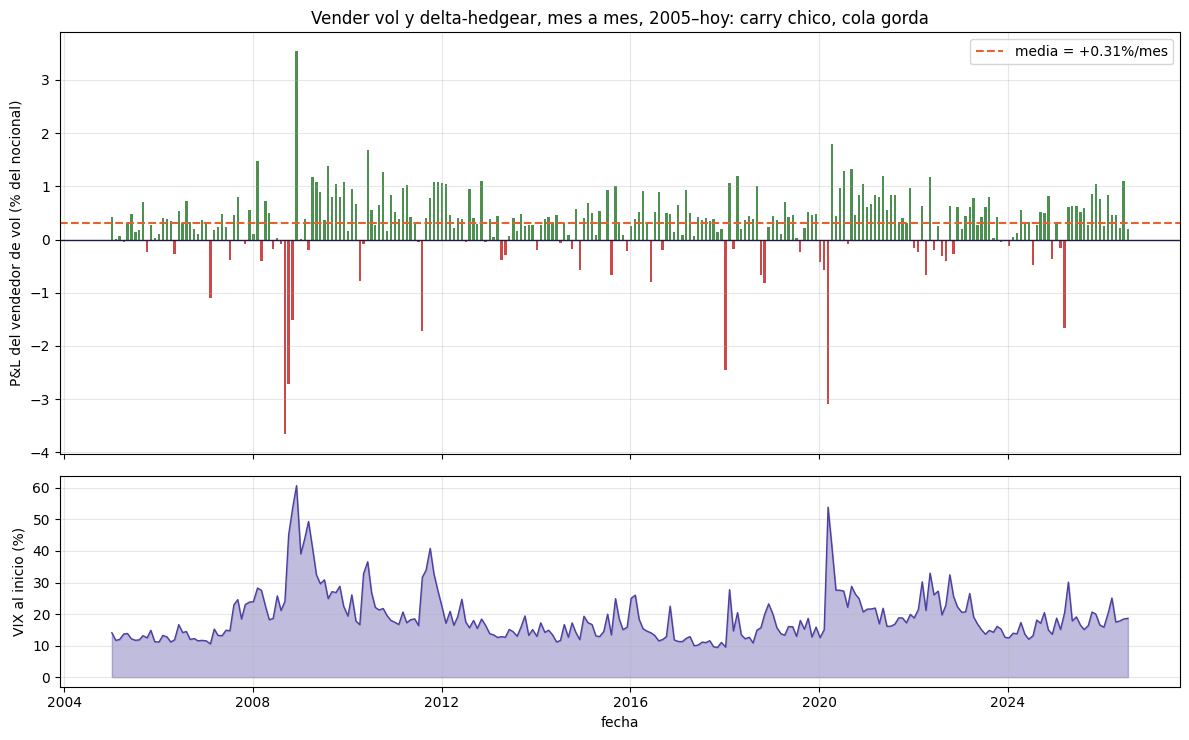

In [16]:
# ── El P&L mes a mes: carry chico y constante, pérdidas grandes y raras ──────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})
colores = [RED if p < 0 else GREEN for p in resultado.pnl_vendedor]
ax1.bar(resultado.index, resultado.pnl_vendedor * 100, width=18, color=colores, alpha=0.85)
ax1.axhline(0, color=NAVY, lw=1)
ax1.axhline(resultado.pnl_vendedor.mean() * 100, color=ORANGE, lw=1.5, ls='--',
            label=f'media = {resultado.pnl_vendedor.mean():+.2%}/mes')
ax1.set_ylabel('P&L del vendedor de vol (% del nocional)')
ax1.set_title('Vender vol y delta-hedgear, mes a mes, 2005–hoy: carry chico, cola gorda')
ax1.legend()

ax2.fill_between(resultado.index, resultado.vix_inicio * 100, color=VIOLET, alpha=0.35)
ax2.plot(resultado.index, resultado.vix_inicio * 100, color=VIOLET, lw=1)
ax2.set_ylabel('VIX al inicio (%)')
ax2.set_xlabel('fecha')

plt.tight_layout()
plt.show()


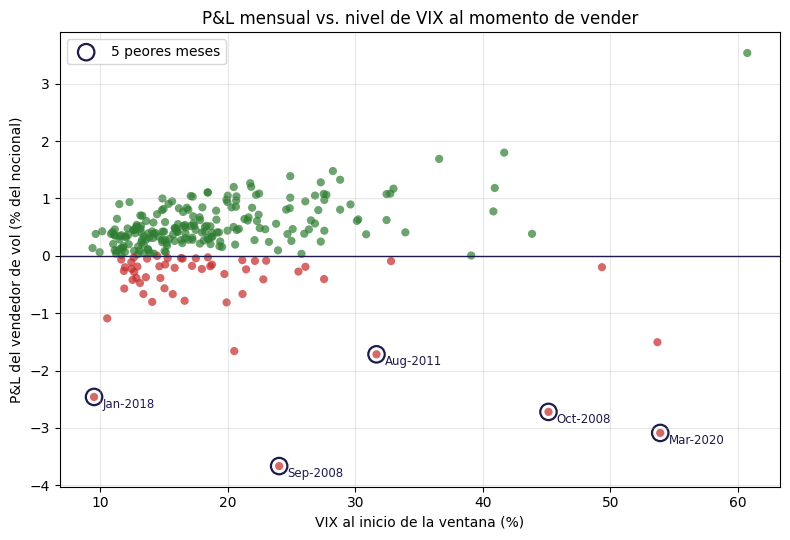

In [17]:
# ── P&L vs. nivel de VIX al vender: ¿el VIX te avisa el riesgo? ──────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
colores = [RED if p < 0 else GREEN for p in resultado.pnl_vendedor]
ax.scatter(resultado.vix_inicio * 100, resultado.pnl_vendedor * 100,
           c=colores, alpha=0.7, s=35, edgecolor='none')
ax.axhline(0, color=NAVY, lw=1)

# destacar los 5 peores meses (misma tabla de la celda anterior)
peores5 = resultado.sort_values('pnl_vendedor').head(5)
ax.scatter(peores5.vix_inicio * 100, peores5.pnl_vendedor * 100, facecolors='none',
           edgecolors=NAVY, s=140, lw=1.6, label='5 peores meses')
for fecha, row in peores5.iterrows():
    ax.annotate(fecha.strftime('%b-%Y'), (row.vix_inicio * 100, row.pnl_vendedor * 100),
                xytext=(6, -8), textcoords='offset points', fontsize=8.5, color=NAVY)

ax.set_xlabel('VIX al inicio de la ventana (%)')
ax.set_ylabel('P&L del vendedor de vol (% del nocional)')
ax.set_title('P&L mensual vs. nivel de VIX al momento de vender')
ax.legend()
plt.tight_layout(); plt.show()
